In [1]:
import sys
import platform

import streamlit
import pandas
import numpy
import sklearn
import xgboost
import matplotlib
import scipy

try:
    import shap
    shap_version = shap.__version__
except:
    shap_version = "Not Installed"

print("=" * 50)
print("PYTHON ENVIRONMENT")
print("=" * 50)

print(f"Python Version      : {sys.version}")
print(f"Platform            : {platform.platform()}")

print("\n" + "=" * 50)
print("LIBRARY VERSIONS")
print("=" * 50)

print(f"streamlit           : {streamlit.__version__}")
print(f"pandas              : {pandas.__version__}")
print(f"numpy               : {numpy.__version__}")
print(f"scikit-learn        : {sklearn.__version__}")
print(f"xgboost             : {xgboost.__version__}")
print(f"matplotlib          : {matplotlib.__version__}")
print(f"scipy               : {scipy.__version__}")
print(f"shap                : {shap_version}")

print("\n" + "=" * 50)
print("REQUIREMENTS.TXT FORMAT")
print("=" * 50)

print(f"streamlit=={streamlit.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"numpy=={numpy.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"xgboost=={xgboost.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"scipy=={scipy.__version__}")

if shap_version != "Not Installed":
    print(f"shap=={shap_version}")

PYTHON ENVIRONMENT
Python Version      : 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Platform            : Windows-11-10.0.26200-SP0

LIBRARY VERSIONS
streamlit           : 1.51.0
pandas              : 2.3.3
numpy               : 2.4.3
scikit-learn        : 1.8.0
xgboost             : 3.2.0
matplotlib          : 3.10.8
scipy               : 1.16.3
shap                : Not Installed

REQUIREMENTS.TXT FORMAT
streamlit==1.51.0
pandas==2.3.3
numpy==2.4.3
scikit-learn==1.8.0
xgboost==3.2.0
matplotlib==3.10.8
scipy==1.16.3


## **Step 1: Data Understanding**

In [1]:
import pandas as pd

df = pd.read_csv(r"D:\Innomatics\6) ML\5) Projects\3) Insurance\1) Final\Insurance claims data.csv")

In [2]:
df.shape

(58592, 41)

In [3]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [5]:
df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000


In [6]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age',
       'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'steering_type', 'turning_radius', 'length',
       'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status'],
      dtype='object')

In [7]:
df.isnull().sum()

policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width                               0
gross_weight

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:\n", categorical_cols)
print("\nNumerical Columns:\n", numerical_cols)

Categorical Columns:
 ['policy_id', 'region_code', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']

Numerical Columns:
 ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'airbags', 'displacement', 'cylinder', 'turning_radius', 'length', 'width', 'gross_weight', 'ncap_rating', 'claim_status']


In [10]:
claim_counts = df["claim_status"].value_counts()

print(claim_counts)

print("\nPercentage Distribution:")
print(df["claim_status"].value_counts(normalize=True) * 100)

claim_status
0    54844
1     3748
Name: count, dtype: int64

Percentage Distribution:
claim_status
0    93.603222
1     6.396778
Name: proportion, dtype: float64


## **Step 2: Data Preprocessing**

### PHASE 1 : WORKING COPY & BASIC CLEANUP

In [11]:
df = df.copy()

In [12]:
print(df.columns.tolist())

['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status']


In [13]:
drop_cols = ["policy_id"]

df.drop(columns=drop_cols, inplace=True)
print(drop_cols)

['policy_id']


In [14]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [15]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")

Duplicate Rows : 1894


In [16]:
initial_shape = df.shape
df = df.drop_duplicates()
final_shape = df.shape

print(f"Initial Shape : {initial_shape}")
print(f"Final Shape   : {final_shape}")

print(f"\nRows Removed : {initial_shape[0] - final_shape[0]}")

Initial Shape : (58592, 40)
Final Shape   : (56698, 40)

Rows Removed : 1894


### PHASE 2 : DOMAIN-BASED FEATURE ENGINEERING

In [17]:
import numpy as np
import pandas as pd

#### 2.1 Extract Numerical Information from max_torque

In [18]:
df["torque_value"] = (
    df["max_torque"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df["torque_rpm"] = (
    df["max_torque"]
    .str.extract(r"@(\d+)")[0]
    .astype(float)
)

#### 2.2 Extract Numerical Information from max_power

In [19]:
df["power_value"] = (
    df["max_power"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df["power_rpm"] = (
    df["max_power"]
    .str.extract(r"@(\d+)")[0]
    .astype(float)
)

#### 2.3 Drop Original Raw Text Columns

In [20]:
df.drop(
    columns=["max_torque", "max_power"],
    inplace=True
)

#### 2.4 Binary Feature Encoding (Yes/No → 1/0)

In [21]:
binary_cols = [
    'is_esc',
    'is_adjustable_steering',
    'is_tpms',
    'is_parking_camera',
    'is_front_fog_lights',
    'is_rear_window_wiper',
    'is_rear_window_washer',
    'is_rear_window_defogger',
    'is_brake_assist',
    'is_power_door_locks',
    'is_central_locking',
    'is_power_steering',
    'is_driver_seat_height_adjustable',
    'is_day_night_rear_view_mirror',
    'is_ecw',
    'is_speed_alert'
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })

#### 2.5 Parking Sensor Feature Engineering

In [22]:
df["is_parking_sensors"] = (
    df["is_parking_sensors"]
    .replace({
        "No": 0,
        "Yes": 1,
        "Rear": 1,
        "Front & Rear": 2
    })
    .infer_objects(copy=False)
)

C:\Users\iamsu\AppData\Local\Temp\ipykernel_19336\1134165032.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


#### 2.6 Total Safety Feature Engineering

In [23]:
safety_cols = [
    'is_esc',
    'is_tpms',
    'is_parking_camera',
    'is_front_fog_lights',
    'is_rear_window_defogger',
    'is_brake_assist',
    'is_ecw',
    'is_speed_alert'
]

df["total_safety_features"] = (
    df[safety_cols]
    .sum(axis=1)
)

#### 2.7 Vehicle Age Group

In [24]:
df["vehicle_age_group"] = pd.cut(
    df["vehicle_age"],
    bins=[-1, 2, 5, 10, 25],
    labels=[
        "New",
        "Moderate",
        "Old",
        "Very_Old"
    ]
)

#### 2.8 Customer Age Group

In [25]:
df["customer_age_group"] = pd.cut(
    df["customer_age"],
    bins=[0, 40, 55, 100],
    labels=[
        "Young",
        "Middle_Age",
        "Senior"
    ]
)

#### 2.9 Engine Power Category

In [26]:
df["power_category"] = pd.cut(
    df["power_value"],
    bins=[0, 70, 100, 250],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

#### 2.10 Power-to-Weight Ratio

In [27]:
df["power_to_weight"] = (df["power_value"] / df["gross_weight"])

#### 2.11 Engine Stress Index

In [28]:
df["engine_stress_index"] = ( df["torque_value"] / df["cylinder"])

#### 2.12 Vehicle Usage Risk

In [29]:
df["vehicle_usage_risk"] = ( df["vehicle_age"] * df["subscription_length"])

#### 2.13 Vehicle Density Risk

In [30]:
df["vehicle_density_risk"] = ( df["region_density"] * df["vehicle_age"])

#### 2.14 Vehicle Risk Score

In [31]:
df["vehicle_risk_score"] = ((df["power_value"] * 0.30) + (df["vehicle_age"] * 0.25) + (df["gross_weight"] * 0.20) - 
                            (df["airbags"] * 0.10) - (df["ncap_rating"] * 0.15))

In [32]:
print(f"\nDataset Shape : {df.shape}")

print("\nNew Engineered Features Added:\n")

new_features = [

    "torque_value",
    "torque_rpm",
    "power_value",
    "power_rpm",
    "total_safety_features",
    "vehicle_age_group",
    "customer_age_group",
    "power_category",
    "power_to_weight",
    "engine_stress_index",
    "vehicle_usage_risk",
    "vehicle_density_risk",
    "vehicle_risk_score"
]

print(new_features)


Dataset Shape : (56698, 51)

New Engineered Features Added:

['torque_value', 'torque_rpm', 'power_value', 'power_rpm', 'total_safety_features', 'vehicle_age_group', 'customer_age_group', 'power_category', 'power_to_weight', 'engine_stress_index', 'vehicle_usage_risk', 'vehicle_density_risk', 'vehicle_risk_score']


### PHASE 3 : DOMAIN-BASED FEATURE REVIEW

#### 3.1 Remove Weak / Redundant Features

In [33]:
remove_features = [

    'is_rear_window_wiper',
    'is_rear_window_washer',
    'is_rear_window_defogger',
    'is_adjustable_steering',
    'is_driver_seat_height_adjustable',
    'is_central_locking',
    'is_front_fog_lights',
    'is_ecw',
    'is_speed_alert'
]

df.drop(
    columns=remove_features,
    inplace=True
)

In [34]:
remove_dimension_features = [
    "length",
    "width"
]

df.drop(
    columns=remove_dimension_features,
    inplace=True
)

print(remove_dimension_features)

['length', 'width']


#### 3.2 Final Feature Verification

In [35]:
print("=" * 60)
print("PHASE 3 FEATURE REVIEW COMPLETED")
print("=" * 60)

print(f"\nDataset Shape : {df.shape}")

print("\nRemoved Features:\n")
print(remove_features)


# ------------------------------------------------------------
# 3.3 Final Column List
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL FEATURES")
print("=" * 60)

final_features = df.drop(
    columns=["claim_status"]
).columns.tolist()

print(final_features)

print(f"\nTotal Features : {len(final_features)}")

PHASE 3 FEATURE REVIEW COMPLETED

Dataset Shape : (56698, 40)

Removed Features:

['is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_adjustable_steering', 'is_driver_seat_height_adjustable', 'is_central_locking', 'is_front_fog_lights', 'is_ecw', 'is_speed_alert']

FINAL FEATURES
['subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type', 'engine_type', 'airbags', 'is_esc', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'gross_weight', 'is_brake_assist', 'is_power_door_locks', 'is_power_steering', 'is_day_night_rear_view_mirror', 'ncap_rating', 'torque_value', 'torque_rpm', 'power_value', 'power_rpm', 'total_safety_features', 'vehicle_age_group', 'customer_age_group', 'power_category', 'power_to_weight', 'engine_stress_index', 'vehicle_usage_risk', 'vehicle_density_risk', 'vehicle_risk_sc

### PHASE 4 : FEATURE ORGANIZATION & DATA SPLITTING

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = df.drop(columns=["claim_status"])
y = df["claim_status"]

print(f"\nX Shape : {X.shape}")
print(f"y Shape : {y.shape}")


X Shape : (56698, 39)
y Shape : (56698,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nX_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")

print(f"\ny_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")


X_train Shape : (45358, 39)
X_test Shape  : (11340, 39)

y_train Shape : (45358,)
y_test Shape  : (11340,)


#### Numerical Features

In [39]:
Numerical_cols = [

    'subscription_length',
    'vehicle_age',
    'customer_age',
    'region_density',
    'airbags',
    'displacement',
    'cylinder',
    'turning_radius',
    'gross_weight',
    'ncap_rating',

    'torque_value',
    'torque_rpm',

    'power_value',
    'power_rpm',

    'total_safety_features',

    'power_to_weight',
    'engine_stress_index',
    'vehicle_usage_risk',
    'vehicle_density_risk',
    'vehicle_risk_score'
]

#### Binary Features

In [40]:
Binary_cols = [
    'is_esc',
    'is_tpms',
    'is_parking_sensors',
    'is_parking_camera',
    'is_brake_assist',
    'is_power_door_locks',
    'is_power_steering',
    'is_day_night_rear_view_mirror'
]

#### Nominal Features

In [41]:
Nominal_cols = [
    'region_code',
    'segment',
    'model',
    'fuel_type',
    'engine_type',
    'rear_brakes_type',
    'transmission_type',
    'steering_type'
]

#### Ordinal Features

In [42]:
Ordinal_cols = [
    'vehicle_age_group',
    'customer_age_group',
    'power_category'
]

vehicle_age_order = [
    'New',
    'Moderate',
    'Old',
    'Very_Old'
]


customer_age_order = [
    'Young',
    'Middle_Age',
    'Senior'
]


power_order = [
    'Low',
    'Medium',
    'High'
]

In [43]:
print(f"\nNumerical Features : {len(Numerical_cols)}")
print(f"Binary Features    : {len(Binary_cols)}")
print(f"Nominal Features   : {len(Nominal_cols)}")
print(f"Ordinal Features   : {len(Ordinal_cols)}")


Numerical Features : 20
Binary Features    : 8
Nominal Features   : 8
Ordinal Features   : 3


In [44]:
total_grouped_features = (

    len(Numerical_cols)
    +
    len(Binary_cols)
    +
    len(Nominal_cols)
    +
    len(Ordinal_cols)
)

print(f"\nGrouped Features : {total_grouped_features}")
print(f"Actual Features  : {X.shape[1]}")


Grouped Features : 39
Actual Features  : 39


### PHASE 5 : PREPROCESSING PIPELINES

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer

import numpy as np

#### 5.1 Numerical Pipeline

In [46]:
Numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    
    (
        "scaler",
        StandardScaler()
    )
])

Numerical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

#### 5.2 Binary Pipeline

In [47]:
Binary_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    )
])

Binary_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has

#### 5.3 Nominal Pipeline

In [48]:
Nominal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

Nominal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation

#### 5.4 Ordinal Pipeline

In [49]:
Ordinal_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",

        OrdinalEncoder(
            categories=[
                vehicle_age_order,
                customer_age_order,
                power_order
            ]
        )
    )
])

Ordinal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation

#### 5.5 Final Column Transformer

In [50]:
Data_preprocessing = ColumnTransformer([
    (
        "Numerical_pipeline",
        Numerical_pipeline,
        Numerical_cols
    ),

    (
        "Binary_pipeline",
        Binary_pipeline,
        Binary_cols
    ),

    (
        "Nominal_pipeline",
        Nominal_pipeline,
        Nominal_cols
    ),

    (
        "Ordinal_pipeline",
        Ordinal_pipeline,
        Ordinal_cols
    )
])

In [51]:
Data_preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical_pipeline', ...), ('Binary_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_nam

#### 5.6 Fit & Transform Training Data

In [52]:
X_train_processed = (
    Data_preprocessing
    .fit_transform(X_train)
)

#### 5.7 Transform Testing Data

In [53]:
X_test_processed = (
    Data_preprocessing
    .transform(X_test)
)

In [54]:
print(f"\nX_train_processed Shape : {X_train_processed.shape}")
print(f"X_test_processed Shape  : {X_test_processed.shape}")


X_train_processed Shape : (45358, 91)
X_test_processed Shape  : (11340, 91)


In [55]:
print(
    f"\nNaN Values in X_train_processed : "
    f"{np.isnan(X_train_processed).sum()}"
)

print(
    f"NaN Values in X_test_processed  : "
    f"{np.isnan(X_test_processed).sum()}"
)


NaN Values in X_train_processed : 0
NaN Values in X_test_processed  : 0


#### Final Pipeline Summary

In [56]:
print(f"""
Numerical Features : {len(Numerical_cols)}
Binary Features    : {len(Binary_cols)}
Nominal Features   : {len(Nominal_cols)}
Ordinal Features   : {len(Ordinal_cols)}
""")


Numerical Features : 20
Binary Features    : 8
Nominal Features   : 8
Ordinal Features   : 3



### PHASE 6 : FINAL PREPROCESSING VALIDATION

In [57]:
import pandas as pd
import numpy as np

#### 6.1 Extract Final Feature Names

In [58]:
final_feature_names = (
    Data_preprocessing
    .get_feature_names_out()
)

#### 6.2 Convert Processed Arrays to DataFrames

In [59]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=final_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=final_feature_names,
    index=X_test.index
)

#### 6.3 Shape Validation

In [60]:
print(f"\nX_train_processed_df : {X_train_processed_df.shape}")
print(f"X_test_processed_df  : {X_test_processed_df.shape}")


X_train_processed_df : (45358, 91)
X_test_processed_df  : (11340, 91)


In [61]:
print(
    f"\nNaN Values in Training Data : "
    f"{X_train_processed_df.isnull().sum().sum()}"
)

print(
    f"NaN Values in Testing Data  : "
    f"{X_test_processed_df.isnull().sum().sum()}"
)


NaN Values in Training Data : 0
NaN Values in Testing Data  : 0


In [62]:
print(
    f"\nInfinite Values in Training Data : "
    f"{np.isinf(X_train_processed_df).sum().sum()}"
)

print(
    f"Infinite Values in Testing Data  : "
    f"{np.isinf(X_test_processed_df).sum().sum()}"
)


Infinite Values in Training Data : 0
Infinite Values in Testing Data  : 0


In [63]:
print("\nTraining Target Distribution:\n")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting Target Distribution:\n")
print(y_test.value_counts(normalize=True) * 100)



Training Target Distribution:

claim_status
0    93.414613
1     6.585387
Name: proportion, dtype: float64

Testing Target Distribution:

claim_status
0    93.412698
1     6.587302
Name: proportion, dtype: float64


In [64]:
display(
    X_train_processed_df.head()
)

,Numerical_pipeline__subscription_length,Numerical_pipeline__vehicle_age,Numerical_pipeline__customer_age,Numerical_pipeline__region_density,Numerical_pipeline__airbags,Numerical_pipeline__displacement,Numerical_pipeline__cylinder,Numerical_pipeline__turning_radius,Numerical_pipeline__gross_weight,Numerical_pipeline__ncap_rating,...,Nominal_pipeline__rear_brakes_type_Disc,Nominal_pipeline__rear_brakes_type_Drum,Nominal_pipeline__transmission_type_Automatic,Nominal_pipeline__transmission_type_Manual,Nominal_pipeline__steering_type_Electric,Nominal_pipeline__steering_type_Manual,Nominal_pipeline__steering_type_Power,Ordinal_pipeline__vehicle_age_group,Ordinal_pipeline__customer_age_group,Ordinal_pipeline__power_category
30118,-0.109439,-1.061265,0.446136,-0.570611,1.555120,1.236497,0.761057,1.515461,1.569567,0.882174,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0
3008,-1.321181,-1.237486,-0.127073,3.093352,-0.623027,-1.398484,-1.313962,-1.123278,-0.952365,-1.284944,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
14362,-0.569901,0.172286,-0.986886,-0.722643,1.555120,1.236497,0.761057,1.515461,1.569567,0.882174,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0
13754,-1.224242,-0.003936,1.019345,-0.570611,1.555120,1.236497,0.761057,1.515461,1.569567,0.882174,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0
23237,0.956893,-0.885043,1.019345,-0.570611,-0.623027,0.117481,0.761057,-0.243699,-0.245281,0.159802,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0


In [65]:
print(f"\nTotal Features : {len(final_feature_names)}")


Total Features : 91


## **STEP 3 : MODEL TRAINING - MULTI-MODEL BENCHMARKING**

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [68]:
baseline_models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(

        random_state=42,

        eval_metric='logloss'
    )
}

In [69]:
baseline_results = []

print("=" * 80)
print("BASELINE MODEL TRAINING STARTED")
print("=" * 80)

for model_name, model in baseline_models.items():

    print("\n" + "=" * 80)
    print(f"MODEL : {model_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train
    )

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    y_pred = model.predict(
        X_test_processed
    )

    # --------------------------------------------------------
    # PROBABILITY PREDICTIONS
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(
            X_test_processed
        )[:, 1]

    else:

        y_prob = y_pred

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    baseline_results.append({

        "Model": model_name,

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1_Score": round(f1, 4),

        "ROC_AUC": round(roc_auc, 4)
    })

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(f"\nAccuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {roc_auc:.4f}")

    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

BASELINE MODEL TRAINING STARTED

MODEL : Logistic Regression

Accuracy  : 0.9341
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.6149

Classification Report:

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     10593
           1       0.00      0.00      0.00       747

    accuracy                           0.93     11340
   macro avg       0.47      0.50      0.48     11340
weighted avg       0.87      0.93      0.90     11340


MODEL : Decision Tree

Accuracy  : 0.8689
Precision : 0.0898
Recall    : 0.1084
F1 Score  : 0.0982
ROC AUC   : 0.5164

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93     10593
           1       0.09      0.11      0.10       747

    accuracy                           0.87     11340
   macro avg       0.51      0.52      0.51     11340
weighted avg       0.88      0.87      0.87     11340


MODEL : Random Fore

In [70]:
baseline_results_df = pd.DataFrame(
    baseline_results
)

baseline_results_df = (
    baseline_results_df
    .sort_values(
        by="F1_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

In [71]:
display(baseline_results_df)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Gaussian Naive Bayes,0.7052,0.0853,0.3574,0.1377,0.5546
1,Decision Tree,0.8689,0.0898,0.1084,0.0982,0.5164
2,Random Forest,0.9233,0.0576,0.0107,0.0181,0.5753
3,Logistic Regression,0.9341,0.0000,0.0000,0.0000,0.6149
4,Gradient Boosting,0.9341,0.0000,0.0000,0.0000,0.6765
5,XGBoost,0.9340,0.0000,0.0000,0.0000,0.6404


## **Step 4 : Imbalance-Aware Model Optimization**

### 4A : ALGORITHM-LEVEL BALANCING

In [73]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

In [72]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

#### 4A.1 CALCULATE SCALE_POS_WEIGHT

In [74]:
negative_class_count = y_train.value_counts()[0]

positive_class_count = y_train.value_counts()[1]

scale_pos_weight_value = (

    negative_class_count
    /
    positive_class_count
)

print("=" * 80)
print("SCALE_POS_WEIGHT VALUE")
print("=" * 80)

print(f"\nScale Pos Weight : {scale_pos_weight_value:.4f}")

SCALE_POS_WEIGHT VALUE

Scale Pos Weight : 14.1851


#### 4A.2 DEFINE BALANCED MODELS

In [75]:
algorithm_level_models = {

    "Logistic Regression Balanced": LogisticRegression(

        class_weight='balanced',

        random_state=42,

        max_iter=1000
    ),

    "Decision Tree Balanced": DecisionTreeClassifier(

        class_weight='balanced',

        random_state=42
    ),

    "Random Forest Balanced": RandomForestClassifier(

        class_weight='balanced',

        random_state=42,

        n_jobs=-1
    ),

    # GradientBoostingClassifier
    # does NOT support class_weight directly

    "Gradient Boosting": GradientBoostingClassifier(

        random_state=42
    ),

    # GaussianNB also does not support class_weight directly

    "Gaussian Naive Bayes": GaussianNB(),

    "XGBoost Weighted": XGBClassifier(

        scale_pos_weight=scale_pos_weight_value,

        random_state=42,

        eval_metric='logloss',

        n_jobs=-1
    )
}

#### 4A.3 TRAIN & EVALUATE MODELS

In [76]:
ALGORITHM_LEVEL_RESULTS = []

print("\n" + "=" * 80)
print("ALGORITHM-LEVEL BALANCED MODEL TRAINING STARTED")
print("=" * 80)

for model_name, model in algorithm_level_models.items():

    print("\n" + "=" * 80)
    print(f"MODEL : {model_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train
    )

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    y_pred_algo = model.predict(
        X_test_processed
    )

    # --------------------------------------------------------
    # PROBABILITY PREDICTIONS
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_prob_algo = model.predict_proba(
            X_test_processed
        )[:, 1]

    else:

        y_prob_algo = y_pred_algo

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred_algo
    )

    precision = precision_score(
        y_test,
        y_pred_algo,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_algo,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_algo,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob_algo
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    ALGORITHM_LEVEL_RESULTS.append({

        "Model": model_name,

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1_Score": round(f1, 4),

        "ROC_AUC": round(roc_auc, 4)
    })

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(f"\nAccuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {roc_auc:.4f}")

    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred_algo,
            zero_division=0
        )
    )


ALGORITHM-LEVEL BALANCED MODEL TRAINING STARTED

MODEL : Logistic Regression Balanced

Accuracy  : 0.5542
Precision : 0.0896
Recall    : 0.6292
F1 Score  : 0.1568
ROC AUC   : 0.6149

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.55      0.70     10593
           1       0.09      0.63      0.16       747

    accuracy                           0.55     11340
   macro avg       0.52      0.59      0.43     11340
weighted avg       0.90      0.55      0.66     11340


MODEL : Decision Tree Balanced

Accuracy  : 0.8711
Precision : 0.0667
Recall    : 0.0736
F1 Score  : 0.0700
ROC AUC   : 0.5005

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     10593
           1       0.07      0.07      0.07       747

    accuracy                           0.87     11340
   macro avg       0.50      0.50      0.50     11340
weighted avg       0.88      0.87      0

In [77]:
ALGORITHM_LEVEL_RESULTS_DF = pd.DataFrame(
    ALGORITHM_LEVEL_RESULTS
)

ALGORITHM_LEVEL_RESULTS_DF = (

    ALGORITHM_LEVEL_RESULTS_DF

    .sort_values(
        by="F1_Score",
        ascending=False
    )

    .reset_index(drop=True)
)

In [78]:
display(ALGORITHM_LEVEL_RESULTS_DF)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,XGBoost Weighted,0.6997,0.1047,0.4712,0.1713,0.6299
1,Logistic Regression Balanced,0.5542,0.0896,0.6292,0.1568,0.6149
2,Gaussian Naive Bayes,0.7052,0.0853,0.3574,0.1377,0.5546
3,Decision Tree Balanced,0.8711,0.0667,0.0736,0.0700,0.5005
4,Random Forest Balanced,0.9233,0.0576,0.0107,0.0181,0.5716
5,Gradient Boosting,0.9341,0.0000,0.0000,0.0000,0.6765


### STEP 4B : DATA-LEVEL BALANCING USING SMOTE

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [80]:
import pandas as pd
import numpy as np

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

#### 4B.1 APPLY SMOTE

In [81]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train_processed,
    y_train
)

#### VERIFY CLASS DISTRIBUTION

In [82]:
print("\nOriginal Training Distribution:\n")

print(y_train.value_counts())

print("\nSMOTE Training Distribution:\n")

print(y_train_smote.value_counts())


Original Training Distribution:

claim_status
0    42371
1     2987
Name: count, dtype: int64

SMOTE Training Distribution:

claim_status
0    42371
1    42371
Name: count, dtype: int64


#### 4B.2 DEFINE SMOTE MODELS

In [83]:
smote_models = {

    "Logistic Regression SMOTE": LogisticRegression(

        random_state=42,

        max_iter=1000
    ),

    "Decision Tree SMOTE": DecisionTreeClassifier(

        random_state=42
    ),

    "Random Forest SMOTE": RandomForestClassifier(

        random_state=42,

        n_jobs=-1
    ),

    "Gradient Boosting SMOTE": GradientBoostingClassifier(

        random_state=42
    ),

    "Gaussian Naive Bayes SMOTE": GaussianNB(),

    "XGBoost SMOTE": XGBClassifier(

        random_state=42,

        eval_metric='logloss',

        n_jobs=-1
    )
}

#### 4B.3 TRAIN & EVALUATE SMOTE MODELS

In [84]:
SMOTE_RESULTS = []

print("\n" + "=" * 80)
print("SMOTE-BASED MODEL TRAINING STARTED")
print("=" * 80)

for model_name, model in smote_models.items():

    print("\n" + "=" * 80)
    print(f"MODEL : {model_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    model.fit(
        X_train_smote,
        y_train_smote
    )

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    y_pred_smote = model.predict(
        X_test_processed
    )

    # --------------------------------------------------------
    # PROBABILITY PREDICTIONS
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_prob_smote = model.predict_proba(
            X_test_processed
        )[:, 1]

    else:

        y_prob_smote = y_pred_smote

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred_smote
    )

    precision = precision_score(
        y_test,
        y_pred_smote,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_smote,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_smote,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob_smote
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    SMOTE_RESULTS.append({

        "Model": model_name,

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1_Score": round(f1, 4),

        "ROC_AUC": round(roc_auc, 4)
    })

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(f"\nAccuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {roc_auc:.4f}")

    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred_smote,
            zero_division=0
        )
    )


SMOTE-BASED MODEL TRAINING STARTED

MODEL : Logistic Regression SMOTE

Accuracy  : 0.5652
Precision : 0.0888
Recall    : 0.6051
F1 Score  : 0.1549
ROC AUC   : 0.6087

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.56      0.71     10593
           1       0.09      0.61      0.15       747

    accuracy                           0.57     11340
   macro avg       0.52      0.58      0.43     11340
weighted avg       0.90      0.57      0.67     11340


MODEL : Decision Tree SMOTE

Accuracy  : 0.8631
Precision : 0.0723
Recall    : 0.0910
F1 Score  : 0.0806
ROC AUC   : 0.5046

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93     10593
           1       0.07      0.09      0.08       747

    accuracy                           0.86     11340
   macro avg       0.50      0.50      0.50     11340
weighted avg       0.88      0.86      0.87     11340


MOD

In [86]:
SMOTE_RESULTS_DF = pd.DataFrame(
    SMOTE_RESULTS
)

SMOTE_RESULTS_DF = (

    SMOTE_RESULTS_DF

    .sort_values(
        by="F1_Score",
        ascending=False
    )

    .reset_index(drop=True)
)

In [87]:
display(SMOTE_RESULTS_DF)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Gradient Boosting SMOTE,0.8485,0.1358,0.2423,0.1740,0.6432
1,Logistic Regression SMOTE,0.5652,0.0888,0.6051,0.1549,0.6087
2,Gaussian Naive Bayes SMOTE,0.3833,0.0710,0.6921,0.1288,0.5501
3,Random Forest SMOTE,0.8888,0.0959,0.0817,0.0882,0.5836
4,Decision Tree SMOTE,0.8631,0.0723,0.0910,0.0806,0.5046
5,XGBoost SMOTE,0.9259,0.2000,0.0415,0.0687,0.6387


In [88]:
# ============================================================
# COMPARISON TABLE :
# BASELINE vs CLASS WEIGHT vs SMOTE
# ============================================================

comparison_table = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gaussian Naive Bayes",
        "Gradient Boosting",
        "XGBoost"
    ],

    # --------------------------------------------------------
    # BASELINE RESULTS
    # --------------------------------------------------------

    "Baseline_F1": [

        0.0000,
        0.0982,
        0.0181,
        0.1377,
        0.0000,
        0.0000
    ],

    "Baseline_ROC_AUC": [

        0.6149,
        0.5164,
        0.5753,
        0.5546,
        0.6765,
        0.6404
    ],

    # --------------------------------------------------------
    # CLASS WEIGHT RESULTS
    # --------------------------------------------------------

    "ClassWeight_F1": [

        0.1568,
        0.0700,
        0.0181,
        0.1377,
        0.0000,
        0.1713
    ],

    "ClassWeight_ROC_AUC": [

        0.6149,
        0.5005,
        0.5716,
        0.5546,
        0.6765,
        0.6299
    ],

    # --------------------------------------------------------
    # SMOTE RESULTS
    # --------------------------------------------------------

    "SMOTE_F1": [

        0.1549,
        0.0806,
        0.0882,
        0.1288,
        0.1740,
        0.0687
    ],

    "SMOTE_ROC_AUC": [

        0.6087,
        0.5046,
        0.5836,
        0.5501,
        0.6432,
        0.6387
    ],

    # --------------------------------------------------------
    # BEST METHOD
    # --------------------------------------------------------

    "Best_Approach": [

        "Class Weight",
        "Baseline",
        "SMOTE",
        "Baseline",
        "SMOTE",
        "Class Weight"
    ]
})

# ============================================================
# DISPLAY FINAL COMPARISON TABLE
# ============================================================

print("=" * 100)
print("BASELINE vs CLASS WEIGHT vs SMOTE COMPARISON")
print("=" * 100)

display(comparison_table)

BASELINE vs CLASS WEIGHT vs SMOTE COMPARISON


,Model,Baseline_F1,Baseline_ROC_AUC,ClassWeight_F1,ClassWeight_ROC_AUC,SMOTE_F1,SMOTE_ROC_AUC,Best_Approach
0,Logistic Regression,0.0000,0.6149,0.1568,0.6149,0.1549,0.6087,Class Weight
1,Decision Tree,0.0982,0.5164,0.0700,0.5005,0.0806,0.5046,Baseline
2,Random Forest,0.0181,0.5753,0.0181,0.5716,0.0882,0.5836,SMOTE
3,Gaussian Naive Bayes,0.1377,0.5546,0.1377,0.5546,0.1288,0.5501,Baseline
4,Gradient Boosting,0.0000,0.6765,0.0000,0.6765,0.1740,0.6432,SMOTE
5,XGBoost,0.0000,0.6404,0.1713,0.6299,0.0687,0.6387,Class Weight


## **STEP 5 : STRATIFIED CROSS VALIDATION**

In [89]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from xgboost import XGBClassifier

#### 5.1 CALCULATE SCALE_POS_WEIGHT

In [90]:
negative_class_count = y_train.value_counts()[0]
positive_class_count = y_train.value_counts()[1]

scale_pos_weight_value = (

    negative_class_count
    /
    positive_class_count
)

#### 5.2 DEFINE FINAL XGBOOST MODEL

In [91]:
final_xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [92]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [95]:
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [96]:
cross_validation_results = cross_validate(
    estimator=final_xgb_model,
    X=X_train_processed,
    y=y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics,
    return_train_score=True,
    n_jobs=-1
)

In [97]:
cross_validation_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    # --------------------------------------------------------
    # TRAIN SCORES
    # --------------------------------------------------------

    "Train Mean": [
        cross_validation_results['train_accuracy'].mean(),
        cross_validation_results['train_precision'].mean(),
        cross_validation_results['train_recall'].mean(),
        cross_validation_results['train_f1'].mean(),
        cross_validation_results['train_roc_auc'].mean()
    ],

    # --------------------------------------------------------
    # VALIDATION SCORES
    # --------------------------------------------------------

    "Validation Mean": [
        cross_validation_results['test_accuracy'].mean(),
        cross_validation_results['test_precision'].mean(),
        cross_validation_results['test_recall'].mean(),
        cross_validation_results['test_f1'].mean(),
        cross_validation_results['test_roc_auc'].mean()
    ]
})

In [98]:
cross_validation_summary.iloc[:, 1:] = (
    cross_validation_summary.iloc[:, 1:]
    .round(4)
)

In [99]:
display(cross_validation_summary)

,Metric,Train Mean,Validation Mean
0,Accuracy,0.7816,0.7164
1,Precision,0.2246,0.0937
2,Recall,0.9435,0.3817
3,F1 Score,0.3628,0.1505
4,ROC AUC,0.9296,0.6049


## **STEP 6 : Hyperparameter Tuning**

In [100]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [101]:
negative_class_count = y_train.value_counts()[0]
positive_class_count = y_train.value_counts()[1]

scale_pos_weight_value = (
    negative_class_count
    /
    positive_class_count
)

print("=" * 80)
print("SCALE_POS_WEIGHT")
print("=" * 80)

print(f"\nScale Pos Weight : {scale_pos_weight_value:.4f}")

SCALE_POS_WEIGHT

Scale Pos Weight : 14.1851


In [102]:
xgb_tuning_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [103]:
xgb_param_grid = {

    # --------------------------------------------------------
    # TREE COMPLEXITY
    # --------------------------------------------------------

    'max_depth': [3, 4, 5, 6],

    'min_child_weight': [1, 3, 5, 7],

    'gamma': [0, 0.1, 0.3, 0.5],

    # --------------------------------------------------------
    # LEARNING CONTROL
    # --------------------------------------------------------

    'learning_rate': [0.01, 0.03, 0.05, 0.1],

    'n_estimators': [100, 200, 300, 500],

    # --------------------------------------------------------
    # OVERFITTING CONTROL
    # --------------------------------------------------------

    'subsample': [0.6, 0.7, 0.8, 0.9],

    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],

    # --------------------------------------------------------
    # REGULARIZATION
    # --------------------------------------------------------

    'reg_alpha': [0, 0.1, 0.5, 1],

    'reg_lambda': [1, 2, 5, 10]
}

In [104]:
stratified_kfold_tuning = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [105]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring='f1',
    cv=stratified_kfold_tuning,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [106]:
print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING STARTED")
print("=" * 80)

xgb_random_search.fit(
    X_train_processed,
    y_train
)


HYPERPARAMETER TUNING STARTED
Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [107]:
best_xgb_model = xgb_random_search.best_estimator_

print("\n" + "=" * 80)
print("BEST PARAMETERS")
print("=" * 80)

print(xgb_random_search.best_params_)


BEST PARAMETERS
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [108]:
print("\n" + "=" * 80)
print("BEST CROSS VALIDATION F1 SCORE")
print("=" * 80)

print(round(xgb_random_search.best_score_, 4))


BEST CROSS VALIDATION F1 SCORE
0.1683


#### y_train_pred_tuned = best_xgb_model.predict(
    X_train_processed
)

y_train_prob_tuned = best_xgb_model.predict_proba(
    X_train_processed
)[:, 1]

In [110]:
y_test_pred_tuned = best_xgb_model.predict(
    X_test_processed
)

y_test_prob_tuned = best_xgb_model.predict_proba(
    X_test_processed
)[:, 1]

#### TRAIN METRICS

In [111]:
train_accuracy = accuracy_score(
    y_train,
    y_train_pred_tuned
)

train_precision = precision_score(
    y_train,
    y_train_pred_tuned,
    zero_division=0
)

train_recall = recall_score(
    y_train,
    y_train_pred_tuned,
    zero_division=0
)

train_f1 = f1_score(
    y_train,
    y_train_pred_tuned,
    zero_division=0
)

train_roc_auc = roc_auc_score(
    y_train,
    y_train_prob_tuned
)

#### TEST METRICS

In [112]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred_tuned
)

test_precision = precision_score(
    y_test,
    y_test_pred_tuned,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_tuned,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_tuned,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_tuned
)

#### FINAL TRAIN vs TEST COMPARISON

In [113]:
tuning_results_df = pd.DataFrame({
    
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Train Score": [
        round(train_accuracy, 4),
        round(train_precision, 4),
        round(train_recall, 4),
        round(train_f1, 4),
        round(train_roc_auc, 4)
    ],

    "Test Score": [
        round(test_accuracy, 4),
        round(test_precision, 4),
        round(test_recall, 4),
        round(test_f1, 4),
        round(test_roc_auc, 4)
    ]
})

In [114]:
display(tuning_results_df)

,Metric,Train Score,Test Score
0,Accuracy,0.5661,0.5626
1,Precision,0.1011,0.1010
2,Recall,0.7084,0.7135
3,F1 Score,0.1770,0.1769
4,ROC AUC,0.6792,0.6787


In [115]:
print(
    classification_report(
        y_test,
        y_test_pred_tuned,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.96      0.55      0.70     10593
           1       0.10      0.71      0.18       747

    accuracy                           0.56     11340
   macro avg       0.53      0.63      0.44     11340
weighted avg       0.91      0.56      0.67     11340



## STEP 6B : REFINED HYPERPARAMETER TUNING

In [116]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [118]:
negative_class_count = y_train.value_counts()[0]
positive_class_count = y_train.value_counts()[1]
scale_pos_weight_value = (
    negative_class_count
    /
    positive_class_count
)

In [119]:
xgb_refined_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

#### REFINED PARAMETER GRID

In [120]:
refined_param_grid = {

    # --------------------------------------------------------
    # TREE CONTROL
    # --------------------------------------------------------

    'max_depth': [2, 3, 4],

    'min_child_weight': [3, 5, 7, 9],

    'gamma': [0.3, 0.5, 0.7, 1.0],

    # --------------------------------------------------------
    # LEARNING CONTROL
    # --------------------------------------------------------

    'learning_rate': [0.01, 0.03, 0.05],

    'n_estimators': [150, 200, 250, 300],

    # --------------------------------------------------------
    # SAMPLING CONTROL
    # --------------------------------------------------------

    'subsample': [0.6, 0.7, 0.8],

    'colsample_bytree': [0.6, 0.7, 0.8],

    # --------------------------------------------------------
    # REGULARIZATION
    # --------------------------------------------------------

    'reg_alpha': [0.1, 0.5, 1, 2],

    'reg_lambda': [5, 7, 10, 15]
}

In [121]:
refined_stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [122]:
refined_random_search = RandomizedSearchCV(
    estimator=xgb_refined_model,
    param_distributions=refined_param_grid,
    n_iter=40,
    scoring='f1',
    cv=refined_stratified_kfold,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [123]:
refined_random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0.3, 0.5, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [124]:
best_refined_xgb_model = (
    refined_random_search.best_estimator_
)

print("\n" + "=" * 80)
print("BEST REFINED PARAMETERS")
print("=" * 80)

print(refined_random_search.best_params_)


BEST REFINED PARAMETERS
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 9, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.6}


In [125]:
print("\n" + "=" * 80)
print("BEST REFINED CROSS VALIDATION F1 SCORE")
print("=" * 80)

print(
    round(
        refined_random_search.best_score_,
        4
    )
)


BEST REFINED CROSS VALIDATION F1 SCORE
0.1693


#### TRAIN PREDICTIONS

In [126]:
y_train_pred_refined = (
    best_refined_xgb_model.predict(
        X_train_processed
    )
)

y_train_prob_refined = (
    best_refined_xgb_model.predict_proba(
        X_train_processed
    )[:, 1]
)


#### TEST PREDICTIONS

In [127]:
y_test_pred_refined = (
    best_refined_xgb_model.predict(
        X_test_processed
    )
)

y_test_prob_refined = (
    best_refined_xgb_model.predict_proba(
        X_test_processed
    )[:, 1]
)

#### TRAIN METRICS

In [128]:
train_accuracy_refined = accuracy_score(
    y_train,
    y_train_pred_refined
)

train_precision_refined = precision_score(
    y_train,
    y_train_pred_refined,
    zero_division=0
)

train_recall_refined = recall_score(
    y_train,
    y_train_pred_refined,
    zero_division=0
)

train_f1_refined = f1_score(
    y_train,
    y_train_pred_refined,
    zero_division=0
)

train_roc_auc_refined = roc_auc_score(
    y_train,
    y_train_prob_refined
)

#### TEST METRICS

In [129]:
test_accuracy_refined = accuracy_score(
    y_test,
    y_test_pred_refined
)

test_precision_refined = precision_score(
    y_test,
    y_test_pred_refined,
    zero_division=0
)

test_recall_refined = recall_score(
    y_test,
    y_test_pred_refined,
    zero_division=0
)

test_f1_refined = f1_score(
    y_test,
    y_test_pred_refined,
    zero_division=0
)

test_roc_auc_refined = roc_auc_score(
    y_test,
    y_test_prob_refined
)

#### FINAL RESULTS TABLE

In [131]:
refined_tuning_results_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Train Score": [
        round(train_accuracy_refined, 4),
        round(train_precision_refined, 4),
        round(train_recall_refined, 4),
        round(train_f1_refined, 4),
        round(train_roc_auc_refined, 4)
    ],

    "Test Score": [
        round(test_accuracy_refined, 4),
        round(test_precision_refined, 4),
        round(test_recall_refined, 4),
        round(test_f1_refined, 4),
        round(test_roc_auc_refined, 4)
    ]
})

In [132]:
display(refined_tuning_results_df)

,Metric,Train Score,Test Score
0,Accuracy,0.5688,0.5681
1,Precision,0.1006,0.1023
2,Recall,0.6990,0.7149
3,F1 Score,0.1760,0.1790
4,ROC AUC,0.6779,0.6787


In [133]:
print(
    classification_report(
        y_test,
        y_test_pred_refined,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.97      0.56      0.71     10593
           1       0.10      0.71      0.18       747

    accuracy                           0.57     11340
   macro avg       0.53      0.64      0.44     11340
weighted avg       0.91      0.57      0.67     11340



In [134]:
# ============================================================
# HYPERPARAMETER TUNING COMPARISON TABLE
# TUNING ROUND 1 vs TUNING ROUND 2
# ============================================================

tuning_comparison_df = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    # --------------------------------------------------------
    # ROUND 1 RESULTS
    # --------------------------------------------------------

    "Tuning_1_Train": [

        0.5661,
        0.1011,
        0.7084,
        0.1770,
        0.6792
    ],

    "Tuning_1_Test": [

        0.5626,
        0.1010,
        0.7135,
        0.1769,
        0.6787
    ],

    # --------------------------------------------------------
    # ROUND 2 RESULTS
    # --------------------------------------------------------

    "Tuning_2_Train": [

        0.5688,
        0.1006,
        0.6990,
        0.1760,
        0.6779
    ],

    "Tuning_2_Test": [

        0.5681,
        0.1023,
        0.7149,
        0.1790,
        0.6787
    ]
})


# ============================================================
# BEST PARAMETER COMPARISON TABLE
# ============================================================

parameter_comparison_df = pd.DataFrame({

    "Parameter": [

        "subsample",
        "reg_lambda",
        "reg_alpha",
        "n_estimators",
        "min_child_weight",
        "max_depth",
        "learning_rate",
        "gamma",
        "colsample_bytree"
    ],

    # --------------------------------------------------------
    # TUNING ROUND 1
    # --------------------------------------------------------

    "Tuning_1": [

        0.8,
        5,
        0,
        200,
        3,
        3,
        0.03,
        0.3,
        0.8
    ],

    # --------------------------------------------------------
    # TUNING ROUND 2
    # --------------------------------------------------------

    "Tuning_2": [

        0.7,
        10,
        0.5,
        200,
        9,
        3,
        0.03,
        0.5,
        0.6
    ]
})


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 100)
print("HYPERPARAMETER TUNING PERFORMANCE COMPARISON")
print("=" * 100)

display(tuning_comparison_df)


print("\n" + "=" * 100)
print("BEST PARAMETER COMPARISON")
print("=" * 100)

display(parameter_comparison_df)

HYPERPARAMETER TUNING PERFORMANCE COMPARISON


,Metric,Tuning_1_Train,Tuning_1_Test,Tuning_2_Train,Tuning_2_Test
0,Accuracy,0.5661,0.5626,0.5688,0.5681
1,Precision,0.1011,0.1010,0.1006,0.1023
2,Recall,0.7084,0.7135,0.6990,0.7149
3,F1 Score,0.1770,0.1769,0.1760,0.1790
4,ROC AUC,0.6792,0.6787,0.6779,0.6787



BEST PARAMETER COMPARISON


,Parameter,Tuning_1,Tuning_2
0,subsample,0.80,0.70
1,reg_lambda,5.00,10.00
2,reg_alpha,0.00,0.50
3,n_estimators,200.00,200.00
4,min_child_weight,3.00,9.00
5,max_depth,3.00,3.00
6,learning_rate,0.03,0.03
7,gamma,0.30,0.50
8,colsample_bytree,0.80,0.60


## **STEP 7 : THRESHOLD TUNING ON FINAL BALANCED XGBOOST**

In [144]:
import pandas as pd
import numpy as np

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [152]:
y_test_prob_refined_threshold = (

    best_refined_xgb_model
    .predict_proba(X_test_processed)[:, 1]
)

In [146]:
refined_thresholds = np.arange(
    0.40,
    0.81,
    0.01
)

In [153]:
refined_threshold_results = []

for threshold in refined_thresholds:

    # --------------------------------------------------------
    # CONVERT PROBABILITIES TO PREDICTIONS
    # --------------------------------------------------------

    y_pred_refined_threshold = (

        y_test_prob_refined_threshold >= threshold

    ).astype(int)

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred_refined_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_refined_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_refined_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_refined_threshold,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_test_prob_refined_threshold
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    refined_threshold_results.append({

        "Threshold": round(threshold, 2),

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1_Score": round(f1, 4),

        "ROC_AUC": round(roc_auc, 4)
    })

In [154]:
refined_threshold_results_df = pd.DataFrame(
    refined_threshold_results
)

In [155]:
best_refined_threshold_df = (
    refined_threshold_results_df
    .sort_values(
        by="F1_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

In [156]:
display(refined_threshold_results_df)

,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,0.40,0.3684,0.0844,0.8715,0.1538,0.6787
1,0.41,0.3852,0.0858,0.8635,0.1561,0.6787
2,0.42,0.4051,0.0877,0.8541,0.1591,0.6787
3,0.43,0.4232,0.0891,0.8407,0.1611,0.6787
4,0.44,0.4432,0.0914,0.8340,0.1648,0.6787
5,0.45,0.4610,0.0920,0.8099,0.1653,0.6787
6,0.46,0.4802,0.0940,0.7979,0.1682,0.6787
7,0.47,0.4987,0.0952,0.7778,0.1697,0.6787
8,0.48,0.5198,0.0973,0.7604,0.1726,0.6787
9,0.49,0.5421,0.0992,0.7363,0.1748,0.6787


In [161]:
print("\n" + "=" * 100)
print("BEST REFINED THRESHOLD")
print("=" * 100)

display(best_refined_threshold_df.head(10))


BEST REFINED THRESHOLD


,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,0.61,0.8376,0.1438,0.2959,0.1935,0.6787
1,0.60,0.8092,0.1335,0.3454,0.1925,0.6787
2,0.59,0.7802,0.1263,0.3949,0.1914,0.6787
3,0.58,0.7592,0.1222,0.4297,0.1903,0.6787
4,0.55,0.6906,0.1138,0.5448,0.1883,0.6787
5,0.57,0.7344,0.1178,0.4672,0.1881,0.6787
6,0.56,0.7123,0.1153,0.5047,0.1877,0.6787
7,0.54,0.6658,0.1104,0.5770,0.1853,0.6787
8,0.53,0.6423,0.1088,0.6158,0.1849,0.6787
9,0.62,0.8599,0.1486,0.2383,0.1830,0.6787


In [160]:
best_refined_threshold = 0.55

print("=" * 80)
print("FINAL BUSINESS-OPTIMIZED THRESHOLD")
print("=" * 80)

print(f"\nSelected Threshold : {best_refined_threshold}")

FINAL BUSINESS-OPTIMIZED THRESHOLD

Selected Threshold : 0.55


## STEP 8 : FINAL MODEL EVALUATION

In [162]:
import pandas as pd
import numpy as np

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [163]:
# ============================================================
# 8.1 FINAL THRESHOLD
# ============================================================

final_threshold = 0.55


# ============================================================
# 8.2 TRAIN PROBABILITIES
# ============================================================

y_train_prob_final = (

    best_refined_xgb_model
    .predict_proba(X_train_processed)[:, 1]
)


# ============================================================
# 8.3 TEST PROBABILITIES
# ============================================================

y_test_prob_final = (

    best_refined_xgb_model
    .predict_proba(X_test_processed)[:, 1]
)


# ============================================================
# 8.4 APPLY FINAL THRESHOLD
# ============================================================

y_train_pred_final = (

    y_train_prob_final >= final_threshold

).astype(int)


y_test_pred_final = (

    y_test_prob_final >= final_threshold

).astype(int)


# ============================================================
# 8.5 TRAIN METRICS
# ============================================================

train_accuracy_final = accuracy_score(
    y_train,
    y_train_pred_final
)

train_precision_final = precision_score(
    y_train,
    y_train_pred_final,
    zero_division=0
)

train_recall_final = recall_score(
    y_train,
    y_train_pred_final,
    zero_division=0
)

train_f1_final = f1_score(
    y_train,
    y_train_pred_final,
    zero_division=0
)

train_roc_auc_final = roc_auc_score(
    y_train,
    y_train_prob_final
)


# ============================================================
# 8.6 TEST METRICS
# ============================================================

test_accuracy_final = accuracy_score(
    y_test,
    y_test_pred_final
)

test_precision_final = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_recall_final = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_f1_final = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_roc_auc_final = roc_auc_score(
    y_test,
    y_test_prob_final
)


In [164]:
final_results_df = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Train Score": [

        round(train_accuracy_final, 4),

        round(train_precision_final, 4),

        round(train_recall_final, 4),

        round(train_f1_final, 4),

        round(train_roc_auc_final, 4)
    ],

    "Test Score": [

        round(test_accuracy_final, 4),

        round(test_precision_final, 4),

        round(test_recall_final, 4),

        round(test_f1_final, 4),

        round(test_roc_auc_final, 4)
    ]
})

In [165]:
display(final_results_df)

,Metric,Train Score,Test Score
0,Accuracy,0.6869,0.6906
1,Precision,0.1117,0.1138
2,Recall,0.5400,0.5448
3,F1 Score,0.1851,0.1883
4,ROC AUC,0.6779,0.6787


In [167]:
final_confusion_matrix = confusion_matrix(

    y_test,
    y_test_pred_final
)

confusion_matrix_df = pd.DataFrame(

    final_confusion_matrix,

    index=[
        "Actual_0",
        "Actual_1"
    ],

    columns=[
        "Predicted_0",
        "Predicted_1"
    ]
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

display(confusion_matrix_df)


CONFUSION MATRIX


,Predicted_0,Predicted_1
Actual_0,7424,3169
Actual_1,340,407


In [168]:
print("\n" + "=" * 100)
print("FINAL CLASSIFICATION REPORT")
print("=" * 100)

print(

    classification_report(

        y_test,

        y_test_pred_final,

        zero_division=0
    )
)


FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     10593
           1       0.11      0.54      0.19       747

    accuracy                           0.69     11340
   macro avg       0.54      0.62      0.50     11340
weighted avg       0.90      0.69      0.77     11340



In [169]:
print("\n" + "=" * 100)
print("FINAL MODEL SUMMARY")
print("=" * 100)

print(f"""
Final Model                : XGBoost Classifier

Imbalance Strategy         : scale_pos_weight

Hyperparameter Strategy    : Refined RandomizedSearchCV

Final Threshold            : {final_threshold}

Business Objective         : Identify risky insurance customers
                             while minimizing financial loss risk
""")


FINAL MODEL SUMMARY

Final Model                : XGBoost Classifier

Imbalance Strategy         : scale_pos_weight

Hyperparameter Strategy    : Refined RandomizedSearchCV

Final Threshold            : 0.55

Business Objective         : Identify risky insurance customers
                             while minimizing financial loss risk



## Step 8 : Final Model

In [171]:
# ============================================================
# STEP 8A : FINAL MODEL
# ============================================================

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# FINAL BUSINESS THRESHOLD
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.55

# ------------------------------------------------------------
# FINAL XGBOOST MODEL
# ------------------------------------------------------------

final_xgb_model = XGBClassifier(

    # --------------------------------------------------------
    # IMBALANCE HANDLING
    # --------------------------------------------------------

    scale_pos_weight=scale_pos_weight_value,

    # --------------------------------------------------------
    # FINAL REFINED HYPERPARAMETERS
    # --------------------------------------------------------

    colsample_bytree=0.6,

    gamma=0.5,

    learning_rate=0.03,

    max_depth=3,

    min_child_weight=9,

    n_estimators=200,

    reg_alpha=0.5,

    reg_lambda=10,

    subsample=0.7,

    # --------------------------------------------------------
    # OTHER SETTINGS
    # --------------------------------------------------------

    eval_metric='logloss',

    random_state=42,

    n_jobs=-1
)

# ------------------------------------------------------------
# FINAL PIPELINE
# ------------------------------------------------------------

final_pipeline = Pipeline([

    ("Data_Preprocessing", Data_preprocessing),

    ("Model", final_xgb_model)
])

# ------------------------------------------------------------
# DISPLAY PIPELINE
# ------------------------------------------------------------

final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data_Preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical_pipeline', ...), ('Binary_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [172]:
# ============================================================
# STEP 8B : TRAIN FINAL PIPELINE ON TRAIN DATA
# ============================================================

final_pipeline.fit(

    X_train,
    y_train
)

print("=" * 80)
print("FINAL PIPELINE TRAINED SUCCESSFULLY")
print("=" * 80)

FINAL PIPELINE TRAINED SUCCESSFULLY


In [173]:
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data_Preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical_pipeline', ...), ('Binary_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [174]:
# ============================================================
# STEP 8C : SAMPLE PREDICTION TEST
# ============================================================

sample_data = X_test.sample(5, random_state=42)

sample_prob = (

    final_pipeline
    .predict_proba(sample_data)[:, 1]
)

sample_pred = (

    sample_prob >= FINAL_THRESHOLD

).astype(int)

results = pd.DataFrame({

    "Predicted_Probability": np.round(
        sample_prob,
        4
    ),

    "Predicted_Class": sample_pred
})

print(results)

   Predicted_Probability  Predicted_Class
0                 0.2015                0
1                 0.2117                0
2                 0.3705                0
3                 0.7352                1
4                 0.4984                0


In [175]:
# ============================================================
# STEP 8D : FINAL MODEL PERFORMANCE
# ============================================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# TEST PROBABILITIES
# ------------------------------------------------------------

y_prob = (

    final_pipeline
    .predict_proba(X_test)[:, 1]
)

# ------------------------------------------------------------
# APPLY FINAL THRESHOLD
# ------------------------------------------------------------

y_pred = (

    y_prob >= FINAL_THRESHOLD

).astype(int)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CLASSIFICATION REPORT")
print("=" * 60)

print(

    classification_report(

        y_test,

        y_pred,

        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONFUSION MATRIX")
print("=" * 60)

print(

    confusion_matrix(

        y_test,

        y_pred
    )
)


FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     10593
           1       0.11      0.54      0.19       747

    accuracy                           0.69     11340
   macro avg       0.54      0.62      0.50     11340
weighted avg       0.90      0.69      0.77     11340


FINAL CONFUSION MATRIX
[[7424 3169]
 [ 340  407]]


In [176]:
# ============================================================
# STEP 8E : FINAL RESULTS DATAFRAME
# ============================================================

final_results = []

final_results.append({

    "Model": "Final Tuned XGBoost",

    "Threshold": FINAL_THRESHOLD,

    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),

    "Precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "F1_Score": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob
    )
})

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

final_results_df = pd.DataFrame(
    final_results
)

final_results_df.index = [""]

final_results_df

,Model,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC
,Final Tuned XGBoost,0.55,0.690564,0.113814,0.544846,0.188295,0.678682


In [177]:
# ============================================================
# STEP 8F : FEATURE IMPORTANCE
# ============================================================

# ------------------------------------------------------------
# GET FEATURE NAMES
# ------------------------------------------------------------

feature_names = final_pipeline.named_steps[
    "Data_Preprocessing"
].get_feature_names_out()

# ------------------------------------------------------------
# CLEAN FEATURE NAMES
# ------------------------------------------------------------

clean_feature_names = []

for feature in feature_names:

    feature = feature.replace(
        "Numerical_pipeline__",
        ""
    )

    feature = feature.replace(
        "Binary_pipeline__",
        ""
    )

    feature = feature.replace(
        "Nominal_pipeline__",
        ""
    )

    feature = feature.replace(
        "Ordinal_pipeline__",
        ""
    )

    feature = feature.replace(
        "_",
        " "
    )

    feature = feature.title()

    clean_feature_names.append(feature)

# ------------------------------------------------------------
# CREATE IMPORTANCE DATAFRAME
# ------------------------------------------------------------

importance_df = pd.DataFrame({

    "Feature": clean_feature_names,

    "Importance": final_pipeline.named_steps[
        "Model"
    ].feature_importances_
})

# ------------------------------------------------------------
# SORT FEATURES
# ------------------------------------------------------------

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

# ------------------------------------------------------------
# TOP 15 FEATURES
# ------------------------------------------------------------

top_features = importance_df.head(15)

print(top_features)

                  Feature  Importance
10           Torque Value    0.066305
0     Subscription Length    0.049965
1             Vehicle Age    0.045489
50              Segment A    0.044130
8            Gross Weight    0.036849
6                Cylinder    0.034518
17     Vehicle Usage Risk    0.033633
19     Vehicle Risk Score    0.032902
18   Vehicle Density Risk    0.029207
5            Displacement    0.028638
4                 Airbags    0.025665
12            Power Value    0.022438
23      Is Parking Camera    0.020150
14  Total Safety Features    0.020046
24        Is Brake Assist    0.019953


In [178]:
# ============================================================
# STEP 8H : FINAL DEPLOYMENT TRAINING
# ============================================================

# ------------------------------------------------------------
# RETRAIN ON COMPLETE DATA
# ------------------------------------------------------------

final_pipeline.fit(

    X,
    y
)

print("=" * 80)
print("FINAL PIPELINE RETRAINED ON COMPLETE DATA")
print("=" * 80)

FINAL PIPELINE RETRAINED ON COMPLETE DATA


In [179]:
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data_Preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical_pipeline', ...), ('Binary_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [180]:
# ============================================================
# STEP 8I : SAVE FINAL MODEL
# ============================================================

import pickle

# ------------------------------------------------------------
# SAVE FINAL PIPELINE
# ------------------------------------------------------------

with open(

    r'D:\Innomatics\6) ML\5) Projects\3) Insurance\1) Final\Streamlit\Final_Insurance_Model.pkl',

    'wb'

) as f:

    pickle.dump(
        final_pipeline,
        f
    )

# ------------------------------------------------------------
# SAVE FINAL THRESHOLD
# ------------------------------------------------------------

with open(

    r'D:\Innomatics\6) ML\5) Projects\3) Insurance\1) Final\Streamlit\Final_Threshold.pkl',

    'wb'

) as f:

    pickle.dump(
        FINAL_THRESHOLD,
        f
    )

print("=" * 80)
print("MODEL & THRESHOLD SAVED SUCCESSFULLY")
print("=" * 80)

MODEL & THRESHOLD SAVED SUCCESSFULLY


In [181]:
# ============================================================
# STEP 8J : RELOAD TEST
# ============================================================

with open(

    r'D:\Innomatics\6) ML\5) Projects\3) Insurance\1) Final\Streamlit\Final_Insurance_Model.pkl',

    'rb'

) as f:

    loaded_model = pickle.load(f)

with open(

    r'D:\Innomatics\6) ML\5) Projects\3) Insurance\1) Final\Streamlit\Final_Threshold.pkl',

    'rb'

) as f:

    loaded_threshold = pickle.load(f)

print("=" * 80)
print("MODEL & THRESHOLD LOADED SUCCESSFULLY")
print("=" * 80)

MODEL & THRESHOLD LOADED SUCCESSFULLY


In [182]:
# ============================================================
# STEP 8K : FINAL PREDICT CHECK
# ============================================================

sample_data = X.sample(5, random_state=42)

sample_prob = (

    loaded_model
    .predict_proba(sample_data)[:, 1]
)

sample_pred = (

    sample_prob >= loaded_threshold

).astype(int)

prediction_results = pd.DataFrame({

    "Predicted_Probability": np.round(
        sample_prob,
        4
    ),

    "Predicted_Class": sample_pred
})

print(prediction_results)

   Predicted_Probability  Predicted_Class
0                 0.5885                1
1                 0.5616                1
2                 0.5383                0
3                 0.3159                0
4                 0.4943                0


## Graphs

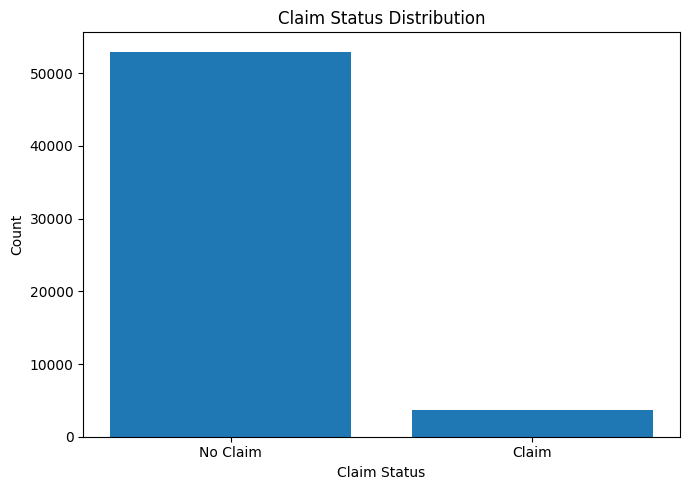

In [183]:
# ============================================================
# GRAPH 1 : TARGET CLASS DISTRIBUTION
# CLAIM vs NO CLAIM
# ============================================================

import matplotlib.pyplot as plt

claim_counts = df["claim_status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(

    ["No Claim", "Claim"],

    claim_counts.values
)

plt.title("Claim Status Distribution")

plt.xlabel("Claim Status")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

C:\Users\iamsu\AppData\Local\Temp\ipykernel_19336\485543354.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


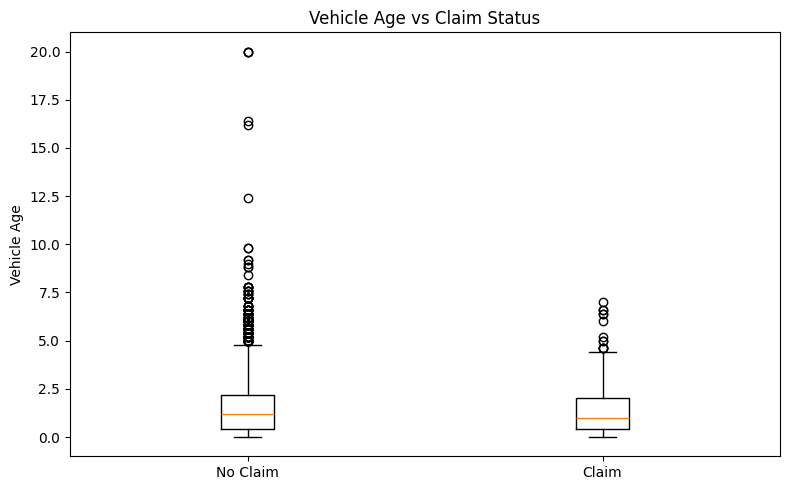

In [184]:
# ============================================================
# GRAPH 2 : VEHICLE AGE vs CLAIM STATUS
# ============================================================

import matplotlib.pyplot as plt

claim_0 = df[df["claim_status"] == 0]["vehicle_age"]

claim_1 = df[df["claim_status"] == 1]["vehicle_age"]

plt.figure(figsize=(8, 5))

plt.boxplot(

    [claim_0, claim_1],

    labels=["No Claim", "Claim"]
)

plt.title("Vehicle Age vs Claim Status")

plt.ylabel("Vehicle Age")

plt.tight_layout()

plt.show()

C:\Users\iamsu\AppData\Local\Temp\ipykernel_19336\3349785637.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


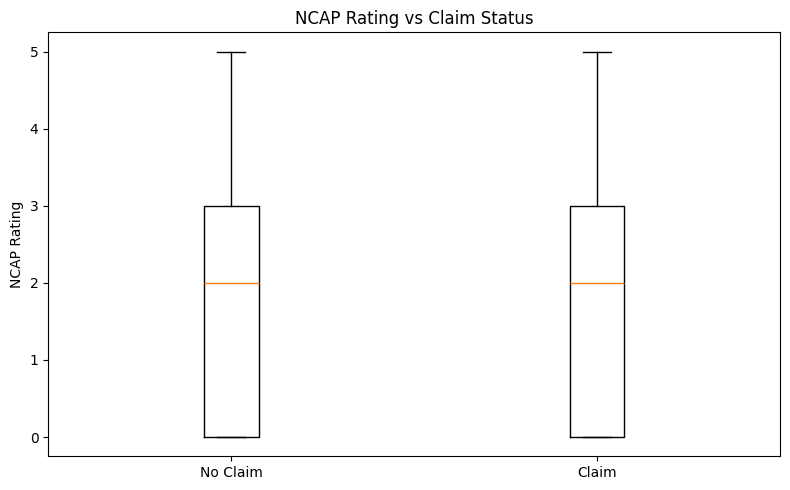

In [185]:
# ============================================================
# GRAPH 3 : NCAP RATING vs CLAIM STATUS
# ============================================================

import matplotlib.pyplot as plt

claim_0 = df[df["claim_status"] == 0]["ncap_rating"]

claim_1 = df[df["claim_status"] == 1]["ncap_rating"]

plt.figure(figsize=(8, 5))

plt.boxplot(

    [claim_0, claim_1],

    labels=["No Claim", "Claim"]
)

plt.title("NCAP Rating vs Claim Status")

plt.ylabel("NCAP Rating")

plt.tight_layout()

plt.show()

C:\Users\iamsu\AppData\Local\Temp\ipykernel_19336\329117097.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


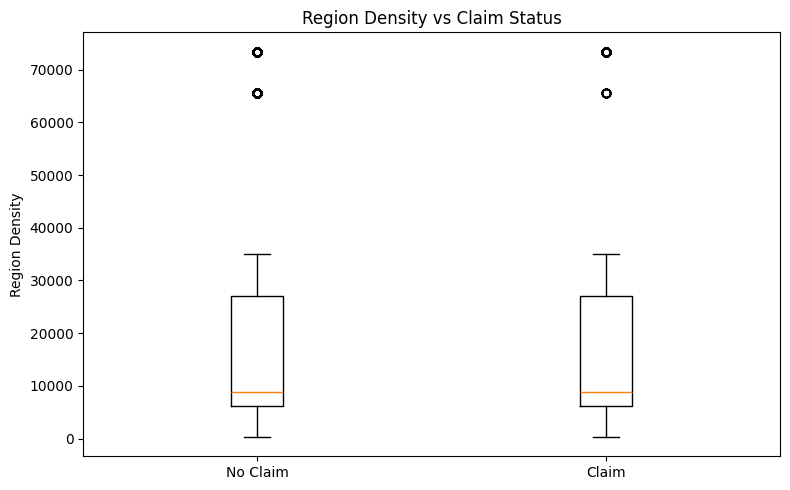

In [186]:
# ============================================================
# GRAPH 4 : REGION DENSITY vs CLAIM STATUS
# ============================================================

import matplotlib.pyplot as plt

claim_0 = df[df["claim_status"] == 0]["region_density"]

claim_1 = df[df["claim_status"] == 1]["region_density"]

plt.figure(figsize=(8, 5))

plt.boxplot(

    [claim_0, claim_1],

    labels=["No Claim", "Claim"]
)

plt.title("Region Density vs Claim Status")

plt.ylabel("Region Density")

plt.tight_layout()

plt.show()

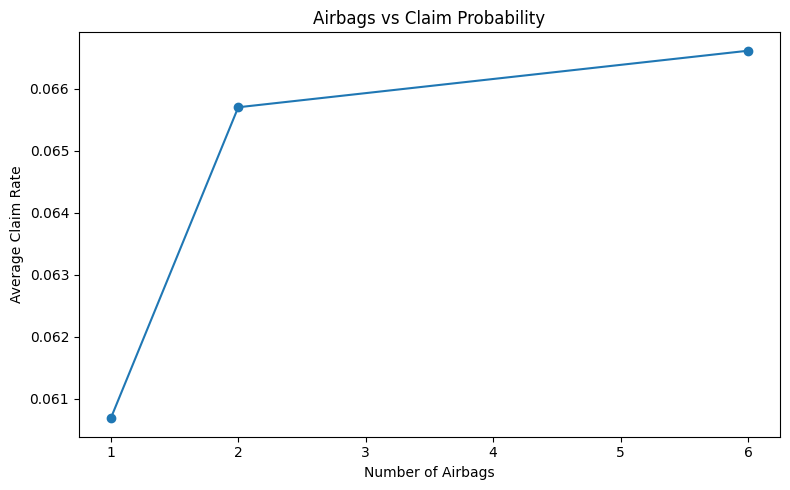

In [188]:
# ============================================================
# GRAPH 5 : AIRBAGS vs CLAIM STATUS
# ============================================================

import matplotlib.pyplot as plt

airbag_claim = (

    df.groupby("airbags")["claim_status"]

    .mean()

    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(

    airbag_claim["airbags"],

    airbag_claim["claim_status"],

    marker='o'
)

plt.title("Airbags vs Claim Probability")

plt.xlabel("Number of Airbags")

plt.ylabel("Average Claim Rate")

plt.tight_layout()

plt.show()

C:\Users\iamsu\AppData\Local\Temp\ipykernel_19336\3710349584.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("power_category")["claim_status"]


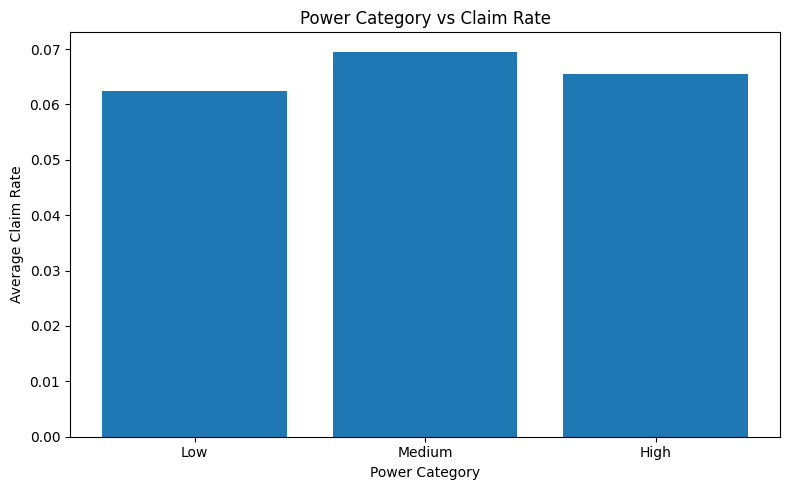

In [189]:
# ============================================================
# GRAPH 6 : CLAIM RATE BY POWER CATEGORY
# ============================================================

import matplotlib.pyplot as plt

power_claim = (

    df.groupby("power_category")["claim_status"]

    .mean()

    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(

    power_claim["power_category"].astype(str),

    power_claim["claim_status"]
)

plt.title("Power Category vs Claim Rate")

plt.xlabel("Power Category")

plt.ylabel("Average Claim Rate")

plt.tight_layout()

plt.show()

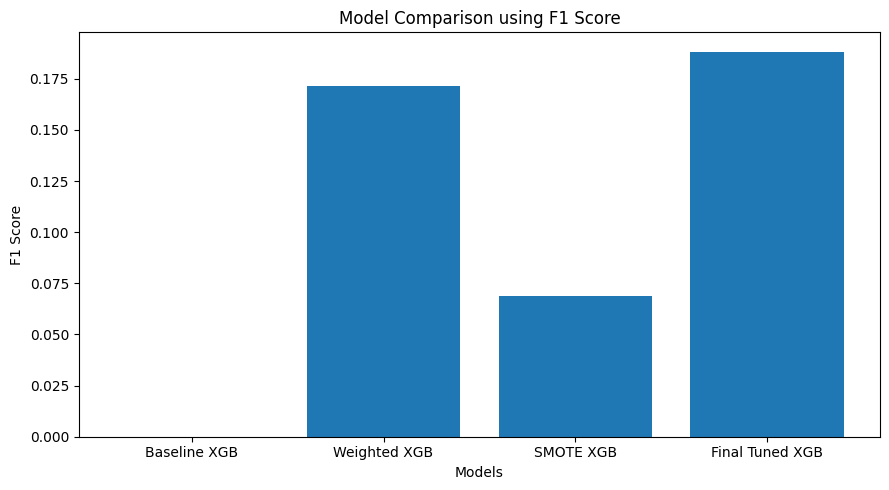

In [190]:
# ============================================================
# GRAPH 7 : MODEL COMPARISON
# ============================================================

import matplotlib.pyplot as plt

model_names = [

    "Baseline XGB",
    "Weighted XGB",
    "SMOTE XGB",
    "Final Tuned XGB"
]

f1_scores = [

    0.0000,
    0.1713,
    0.0687,
    0.1883
]

plt.figure(figsize=(9, 5))

plt.bar(

    model_names,

    f1_scores
)

plt.title("Model Comparison using F1 Score")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.tight_layout()

plt.show()

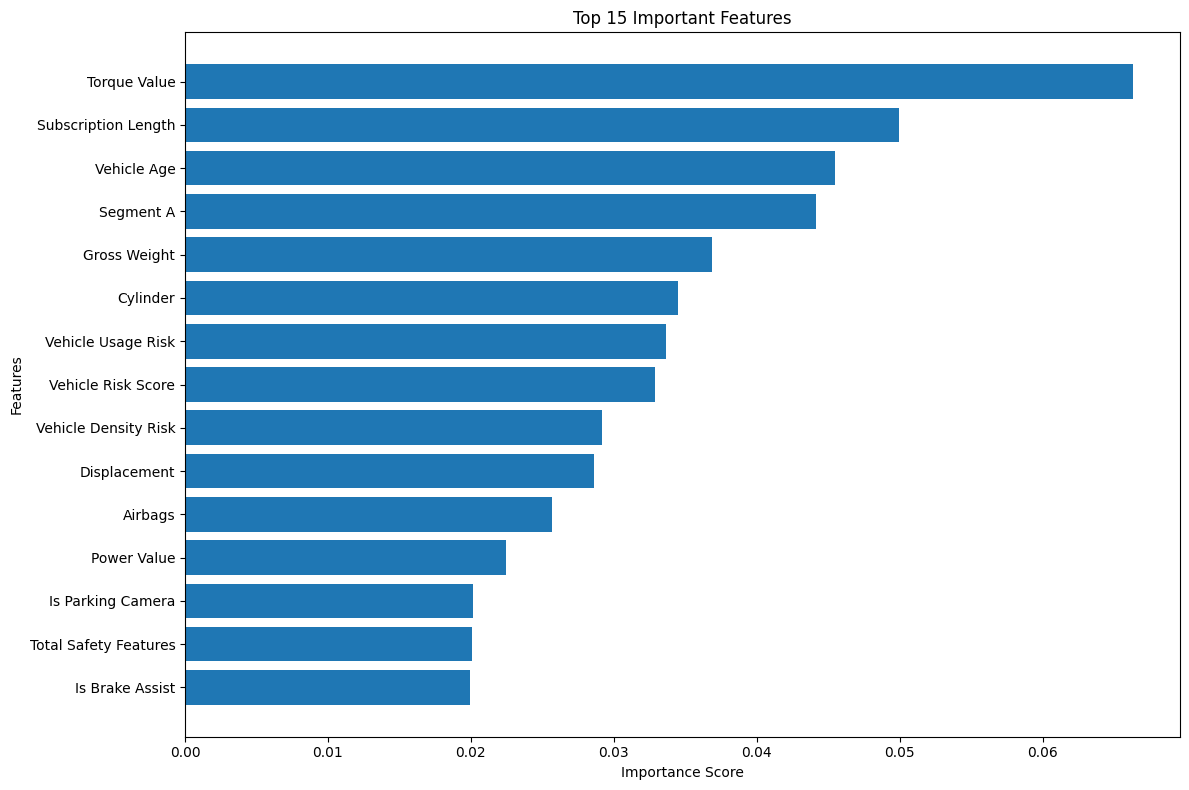

In [191]:
# ============================================================
# GRAPH 8 : TOP 15 FEATURE IMPORTANCE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.barh(

    top_features["Feature"][::-1],

    top_features["Importance"][::-1]
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()